In [10]:
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

import gpjax as gpx
import optax as ox
import paramax as px

from blackjax.util import run_inference_algorithm
from sklearn.preprocessing import StandardScaler

from non_parametric_pro import ula
from non_parametric_pro.density import ProParameters, pro_logdensity_fn, pro_score_fn
from non_parametric_pro.ula import parametric_ula
from non_parametric_pro.util import prediction_basis, nlpd_gp, nlpd_pro, train_val_split
from non_parametric_pro.data.uci import load_uci_regression_dataset
from non_parametric_pro.adaptation.parameter_adaptation import parameter_adaptation
from non_parametric_pro.inducing import PointInducingBasis, compute_inducing_basis, kmeans_inducing_points
from non_parametric_pro.gp import _full_gp_basis, predictive_log_likelihood

jax.config.update("jax_enable_x64", True)

In [23]:
dataset_name = "forest"
split = 1

num_inducing_points = 350
val_fraction = 0.2

num_particles = 40

In [24]:
key = jr.PRNGKey(0)

example = load_uci_regression_dataset(dataset_name, split=split)

scaler_x = StandardScaler()
scaler_y = StandardScaler()

x_train_full = scaler_x.fit_transform(example.x_train)
y_train_full = scaler_y.fit_transform(example.y_train)

split = train_val_split(key, x_train_full, y_train_full, val_fraction=val_fraction)
x_train, y_train = split.x_train, split.y_train
x_val, y_val = split.x_val, split.y_val

x_test = scaler_x.transform(example.x_test)
y_test = scaler_y.transform(example.y_test)

In [25]:
M = num_inducing_points
D = x_train.shape[1]
N = x_train.shape[0]

data = gpx.Dataset(X=x_train_full, y=y_train_full)
kernel = gpx.kernels.Matern32(lengthscale=jnp.ones((D,)))
prior = gpx.gps.Prior(mean_function=gpx.mean_functions.Zero(), kernel=kernel)
likelihood = gpx.likelihoods.Gaussian(num_datapoints=data.n)
posterior = prior * likelihood
optim = ox.adam(learning_rate=0.01)

z_init = kmeans_inducing_points(key, x_train_full, M).z 

variational_family = gpx.variational_families.CollapsedVariationalGaussian(
    posterior=posterior,
    inducing_inputs=z_init,
)

opt_variational_family, _ = gpx.fit(
    model=variational_family,
    objective=lambda p, d: -gpx.objectives.collapsed_elbo(p, d),
    train_data=data,
    optim=optim,
    num_iters=500,
    verbose=False,
)

v_gp_posterior = opt_variational_family.posterior

v_gp_latent_dist = v_gp_posterior.predict(x_test, train_data=data)
v_gp_predictive_dist = v_gp_posterior.likelihood(v_gp_latent_dist)

v_gp_predictive_mean = v_gp_predictive_dist.mean
v_gp_predictive_std = jnp.sqrt(v_gp_predictive_dist.variance)

v_gp_sigma = v_gp_posterior.likelihood.obs_stddev
v_gp_kernel = v_gp_posterior.prior.kernel

z_opt = px.unwrap(opt_variational_family.inducing_inputs)

print("VGP NLPD:", nlpd_gp(y_test, v_gp_predictive_mean, v_gp_predictive_std))

VGP NLPD: 1.392476007741449


In [26]:
px.unwrap(v_gp_sigma)

Array(0.93790471, dtype=float64)

Running parameter adaptation


<div><progress max="10000" value="10000"></progress> 100.00% [10000/10000 00:00&lt;?]</div>

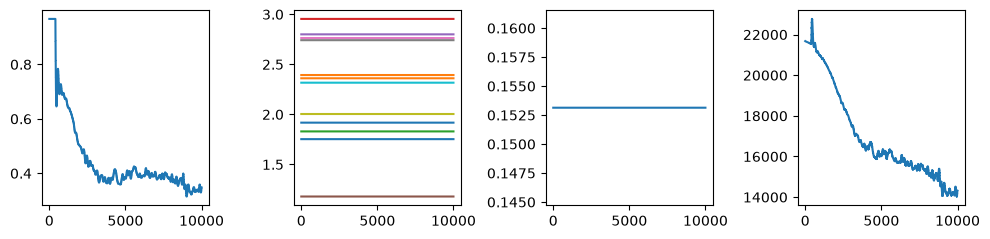

In [14]:
J = num_particles

pro_kernel = v_gp_kernel

_sigma_val = px.unwrap(v_gp_sigma)
_sigma_min = 0.1

inducing_basis = PointInducingBasis(z_opt)
basis, residual_std = compute_inducing_basis(inducing_basis, pro_kernel, x_train)

sigma = gpx.parameters.SigmoidBounded(_sigma_val, low=_sigma_min, high=100.0)

pro_params = ProParameters(
    y=y_train,
    basis=basis,
    step_size=1e-4,
    sigma=sigma,
    alpha=1.0,
    residual_std=residual_std
)

num_steps = 10000
warmup_steps = 400
sigma_adapt_every = 10
kernel_adapt_every = -1
initial_position = jr.normal(key, (M, J))

adaptation = parameter_adaptation(
    ula,
    pro_logdensity_fn,
    pro_params,
    x_train=x_train,
    initial_kernel=pro_kernel,
    warmup_steps=warmup_steps,
    sigma_adapt_every=sigma_adapt_every,
    kernel_adapt_every=kernel_adapt_every,
    objective_fn=pro_score_fn,
    inducing_basis=inducing_basis,
    sigma_optimizer=ox.adam(1e-1),
    kernel_optimizer=ox.adam(1e-2),
    x_val=x_val,
    y_val=y_val,
    progress_bar=True
)

adaptation_results, adaptation_info = adaptation.run(key, initial_position, num_steps=num_steps)
pro_kernel = jax.tree.map(lambda x: x[-1], adaptation_info.kernel)
pro_params = adaptation_results.parameters
pro_position = adaptation_results.state.position

fig, ax = plt.subplots(1, 4, figsize=(10, 2.5))

ax[0].plot(px.unwrap(adaptation_info.sigma))
ax[1].plot(px.unwrap(adaptation_info.kernel.lengthscale))
ax[2].plot(px.unwrap(adaptation_info.kernel.variance))
ax[3].plot(-adaptation_info.sampler_info.score[10:])
plt.tight_layout()
plt.show()

In [15]:
_basis, _residual_std = compute_inducing_basis(inducing_basis, pro_kernel, x_train_full)

pro_params = pro_params._replace(step_size=0.0001)
pro_params = pro_params._replace(basis=_basis)
pro_params = pro_params._replace(residual_std=_residual_std)
pro_params = pro_params._replace(y=y_train_full)

<div><progress max="20000" value="20000"></progress> 100.00% [20000/20000 00:00&lt;?]</div>

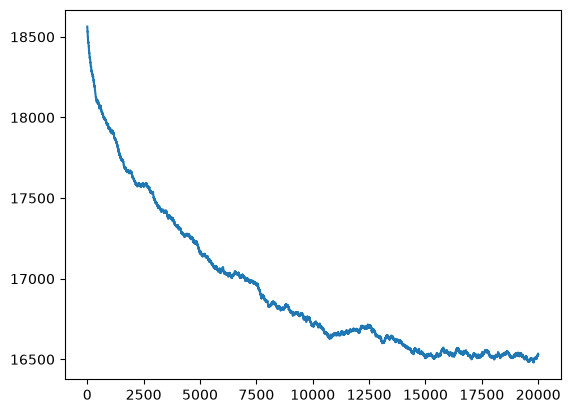

In [18]:
num_steps = 20000
algorithm = parametric_ula(pro_logdensity_fn, pro_params)

out, info = run_inference_algorithm(
    rng_key=key,
    inference_algorithm=algorithm,
    num_steps=num_steps,
    initial_position=pro_position,
    progress_bar=True
)

plt.plot(-info[1].score)
plt.show()

In [19]:
burn = int(num_steps * 0.8)
thin = 50

particles = info[0].position[burn::thin]
test_basis, test_cov = prediction_basis(pro_kernel, x_train, x_test, pro_params, inducing_basis=inducing_basis)

print("PRO NLPD:", nlpd_pro(y_test, test_basis, test_cov, particles, parameters=pro_params))
print("VGP NLPD:", nlpd_gp(y_test, v_gp_predictive_mean, v_gp_predictive_std))


PRO NLPD: 1.2534532528275302
VGP NLPD: 1.370163062097936
